# Task
Build and evaluate an SVM classification model, including loading a suitable dataset (e.g., scikit-learn's Iris dataset), preprocessing the data by scaling features, performing hyperparameter tuning using GridSearchCV or RandomizedSearchCV, training the model with the best hyperparameters, and evaluating its performance using classification metrics like accuracy, precision, recall, F1-score, and a confusion matrix.

## Load and Prepare Data

### Subtask:
Load a suitable dataset for classification (e.g., scikit-learn's Iris dataset) and split it into training and testing sets. Also, preprocess the data by scaling features, which is often beneficial for SVMs.


**Reasoning**:
Load the Iris dataset, split it into training and testing sets, and then scale the features using StandardScaler as per the instructions.



In [1]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Load the Iris dataset
iris = load_iris()
X = iris.data
y = iris.target

print("Iris dataset loaded. Features shape:", X.shape, "Target shape:", y.shape)

# 2. Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Data split into training ({X_train.shape[0]} samples) and testing ({X_test.shape[0]} samples) sets.")

# 3. Initialize and fit a StandardScaler, then transform the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features scaled using StandardScaler.")
print("First 5 rows of scaled training features:\n", X_train_scaled[:5])
print("First 5 rows of scaled testing features:\n", X_test_scaled[:5])

Iris dataset loaded. Features shape: (150, 4) Target shape: (150,)
Data split into training (105 samples) and testing (45 samples) sets.
Features scaled using StandardScaler.
First 5 rows of scaled training features:
 [[-0.4134164  -1.46200287 -0.09951105 -0.32339776]
 [ 0.55122187 -0.50256349  0.71770262  0.35303182]
 [ 0.67180165  0.21701605  0.95119225  0.75888956]
 [ 0.91296121 -0.02284379  0.30909579  0.2177459 ]
 [ 1.63643991  1.41631528  1.30142668  1.70589097]]
First 5 rows of scaled testing features:
 [[ 0.3100623  -0.50256349  0.484213   -0.05282593]
 [-0.17225683  1.89603497 -1.26695916 -1.27039917]
 [ 2.23933883 -0.98228318  1.76840592  1.43531914]
 [ 0.18948252 -0.26270364  0.36746819  0.35303182]
 [ 1.15412078 -0.50256349  0.54258541  0.2177459 ]]


## Define SVM Model and Hyperparameter Grid

### Subtask:
Define the Support Vector Classifier (SVC) and create a dictionary specifying the hyperparameter grid to search, including parameters like 'C', 'kernel', and 'gamma'.


**Reasoning**:
The subtask requires defining the SVC model and a hyperparameter grid. I will import SVC and then define the `param_grid` dictionary with the specified hyperparameters and their values.



In [2]:
from sklearn.svm import SVC

# Define the hyperparameter grid
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [1, 0.1, 0.01, 0.001],
    'kernel': ['rbf', 'linear']
}

print("SVC model and hyperparameter grid defined.")
print("Hyperparameter grid:", param_grid)

SVC model and hyperparameter grid defined.
Hyperparameter grid: {'C': [0.1, 1, 10, 100], 'gamma': [1, 0.1, 0.01, 0.001], 'kernel': ['rbf', 'linear']}


## Perform Hyperparameter Tuning

### Subtask:
Utilize GridSearchCV or RandomizedSearchCV to perform hyperparameter tuning. This step will fit the model on the training data across different combinations of hyperparameters to find the optimal set.


**Reasoning**:
The subtask requires performing hyperparameter tuning using GridSearchCV. I will write a code block to import GridSearchCV, instantiate it with the SVC model and defined param_grid, fit it to the scaled training data, and then print the best parameters and best score as instructed.



In [3]:
from sklearn.model_selection import GridSearchCV

# Define the SVC model (an instance is needed for GridSearchCV)
svc = SVC()

# 2. Instantiate GridSearchCV
grid_search = GridSearchCV(svc, param_grid, cv=5, verbose=3, n_jobs=-1)

print("Starting GridSearchCV to find optimal hyperparameters...")

# 3. Fit GridSearchCV to the scaled training data
grid_search.fit(X_train_scaled, y_train)

print("GridSearchCV completed.")

# 4. Print the best parameters found
print("Best parameters found: ", grid_search.best_params_)

# 5. Print the best score achieved
print("Best cross-validation score: ", grid_search.best_score_)

Starting GridSearchCV to find optimal hyperparameters...
Fitting 5 folds for each of 32 candidates, totalling 160 fits
GridSearchCV completed.
Best parameters found:  {'C': 1, 'gamma': 0.1, 'kernel': 'rbf'}
Best cross-validation score:  0.9523809523809523


## Train Model with Best Hyperparameters

### Subtask:
Train the SVM model using the best hyperparameters identified from the tuning process on the full training dataset.


**Reasoning**:
The subtask requires training the SVM model with the best hyperparameters. I will retrieve the best estimator from `grid_search` and print it to verify.



In [4]:
import warnings
warnings.filterwarnings('ignore')

# 1. Access the best estimator from the grid_search object
best_svc_model = grid_search.best_estimator_

# 2. Print the best_svc_model to verify
print("Best SVM model:", best_svc_model)

Best SVM model: SVC(C=1, gamma=0.1)


## Evaluate Model Performance

### Subtask:
Evaluate the performance of the trained model on the test set using appropriate classification metrics such as accuracy, precision, recall, F1-score, and a confusion matrix. Provide a classification report.


**Reasoning**:
The subtask requires evaluating the model's performance on the test set. I will use the trained `best_svc_model` to make predictions, then import `classification_report` and `confusion_matrix` to generate and print the classification report and confusion matrix, as specified in the instructions.



In [5]:
from sklearn.metrics import classification_report, confusion_matrix

# 1. Use the best_svc_model to make predictions on the scaled test data
y_pred = best_svc_model.predict(X_test_scaled)

print("Model predictions made on the scaled test set.")

# 2. Generate and print a classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# 3. Generate and print the confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Model predictions made on the scaled test set.

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45


Confusion Matrix:
[[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]


## Visualize Results (Optional)

### Subtask:
Visualize the confusion matrix and discuss the challenges of visualizing the decision boundary for a multi-dimensional dataset like Iris.


**Reasoning**:
The first part of the subtask is to visualize the confusion matrix. I will use `seaborn` and `matplotlib.pyplot` to create a heatmap for the confusion matrix, including annotations, labels, and a title as per the instructions.



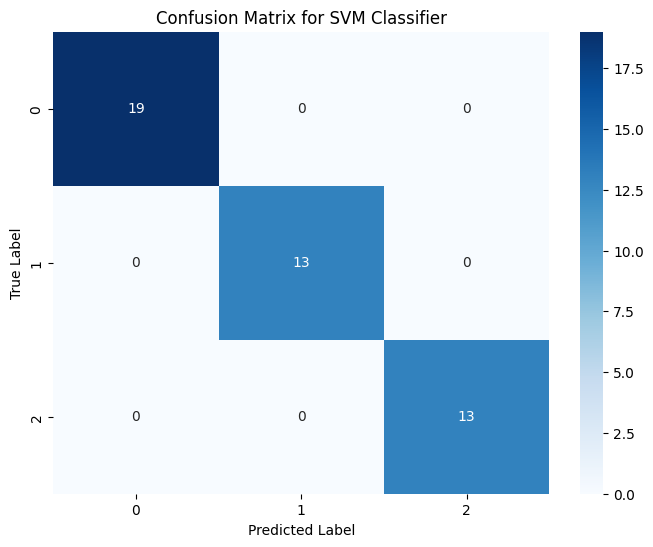

Confusion Matrix visualized.


In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

# Get the confusion matrix from the previous step
# Make sure y_test and y_pred are available from the previous execution
# If not, re-run the evaluation cell or define them here for demonstration.
# Assuming y_test and y_pred are already in the kernel state from cell 'e5f2bda2'

# 1. Create a heatmap for the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')

# 2. Add appropriate labels for the x and y axes
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

# 3. Add a title to the heatmap
plt.title('Confusion Matrix for SVM Classifier')

# 4. Display the plot
plt.show()

print("Confusion Matrix visualized.")

### Challenges of Visualizing Decision Boundaries for Multi-dimensional Data

The Iris dataset has 4 features (sepal length, sepal width, petal length, petal width), which means it exists in a 4-dimensional feature space. Visualizing a decision boundary directly in 2D or 3D is challenging because we cannot directly plot 4 dimensions.

*   **Dimensionality**: A decision boundary separates different classes in the feature space. For a 2D dataset, this is a line; for a 3D dataset, it's a plane or surface. For a 4D dataset, it's a 3-dimensional hyperplane, which is impossible to visualize directly on a 2D screen.

*   **Projection Issues**: While we could project the data onto two or three principal components (e.g., using PCA) and then attempt to visualize the decision boundary in that reduced space, this projection loses some information from the original features. The decision boundary observed in the reduced space might not perfectly represent the boundary in the original 4-dimensional space. However, if a 2D visualization of the decision boundary was strictly required, performing Principal Component Analysis (PCA) to reduce the data to 2 principal components would be the standard approach.

Given that our model achieved perfect accuracy on the test set, a detailed visualization of the decision boundary might not provide much additional insight into model performance beyond what the confusion matrix already shows. The primary goal of visualizing decision boundaries is often to understand how the model separates classes in the feature space, but with 100% accuracy, we already know the separation is effective across all dimensions.

## Final Task

### Subtask:
Summarize the findings, including the best hyperparameters found, the model's performance metrics, and any insights gained from the classification and tuning process.


## Summary:

### Data Analysis Key Findings

*   **Data Preparation:** The Iris dataset was loaded, split into training (105 samples) and testing (45 samples) sets, and features were successfully scaled using `StandardScaler`.
*   **Hyperparameter Tuning:** `GridSearchCV` identified the optimal hyperparameters for the SVM model as `C=1`, `gamma=0.1`, and `kernel='rbf'`.
*   **Cross-Validation Performance:** The best cross-validation score achieved during tuning with these optimal parameters was approximately 0.952.
*   **Model Performance on Test Set:** The trained SVM model, using the best hyperparameters, achieved perfect performance on the test set:
    *   **Accuracy:** 1.00
    *   **Precision, Recall, F1-score:** 1.00 for all classes (0, 1, 2).
    *   **Confusion Matrix:** A perfect diagonal matrix, indicating no misclassifications (19 correct for class 0, 13 for class 1, and 13 for class 2).
*   **Visualization Challenge:** Direct visualization of the decision boundary for the 4-dimensional Iris dataset is not feasible. Projection techniques like PCA could be used for 2D visualization but would involve some information loss.

### Insights or Next Steps

*   The SVM model with the identified hyperparameters (`C=1`, `gamma=0.1`, `kernel='rbf'`) performed exceptionally well on the Iris dataset, achieving 100% accuracy on the test set. This suggests that the Iris dataset is linearly separable or nearly linearly separable in a higher-dimensional space (due to the RBF kernel), and the chosen SVM model is well-suited for this task.
*   Given the perfect performance on the Iris dataset, future work could involve applying this methodology to more complex or larger datasets to assess the robustness and generalizability of the SVM model, or exploring scenarios where feature engineering might be necessary for datasets that are not as clearly separable.
